# K-Nearest Neighbors (KNN) Baseline Model

This notebook trains a baseline KNN model using the PCA-reduced data from the preprocessing step.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
# Load data from the pre-processing folder
X_train = pd.read_csv('../pre-processing/X_train_pca.csv')
X_test = pd.read_csv('../pre-processing/X_test_pca.csv')
y_train = pd.read_csv('../pre-processing/y_train.csv')
y_test = pd.read_csv('../pre-processing/y_test.csv')

# Convert targets to 1D arrays (required by scikit-learn)
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (20783, 15)
Testing Features Shape: (5196, 15)


### Initialize and Train the KNN Model

In [7]:
# We will use the default k=5 for our baseline
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


### Evaluate the Model

In [8]:
# Generate predictions
y_pred = knn.predict(X_test)

# 1. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# 2. Classification Report
print("Classification Report:")
print("0 = Draw, 1 = Home Win, 2 = Home Loss\n")
print(classification_report(y_test, y_pred))

Overall Accuracy: 43.48%

Classification Report:
0 = Draw, 1 = Home Win, 2 = Home Loss

              precision    recall  f1-score   support

           0       0.28      0.31      0.30      1333
           1       0.51      0.62      0.56      2304
           2       0.44      0.27      0.33      1559

    accuracy                           0.43      5196
   macro avg       0.41      0.40      0.40      5196
weighted avg       0.43      0.43      0.42      5196



### Confusion Matrix

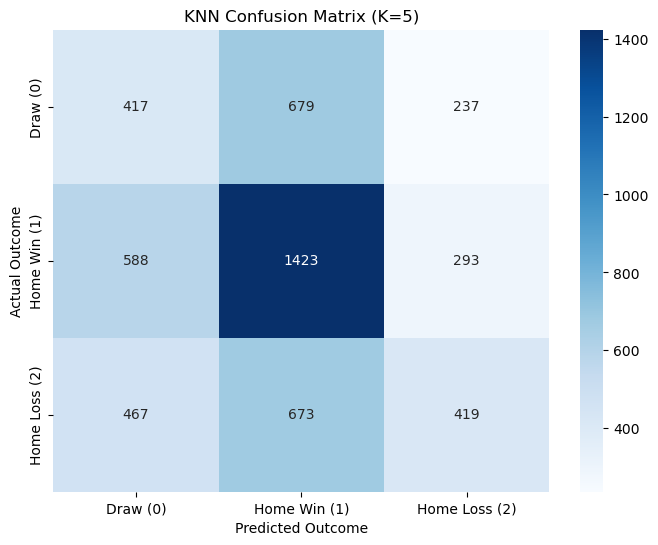

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Draw (0)', 'Home Win (1)', 'Home Loss (2)'], yticklabels=['Draw (0)', 'Home Win (1)', 'Home Loss (2)'])
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.title('KNN Confusion Matrix (K=5)')
plt.show()